# 03 - Feature Engineering

## Objective
Build the modeling-ready feature set from weekly sales + weather data.

## Features Created
1. **Seasonality** — Fourier terms (week-of-year)
2. **Calendar** — holidays, season flags, year index
3. **Weather** — raw values + deviation z-scores from monthly norms
4. **Sales lags** — 1w, 2w, 4w lags + 4-week rolling mean/std


## Input
- `data/processed/weekly_sales_weather.csv`

## Output
- `data/processed/modeling_dataset.csv`
---

---
## Cell 1: Imports
---

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: Load Data
---

In [18]:
df = pd.read_csv(DATA_PROCESSED / 'weekly_units_weather.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])
df = df.sort_values(['store_code','division_code','week_ending']).reset_index(drop=True)

GROUP_COLS = ['store_code','city','division_code']

print(f'Dataset: {df.shape}')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Columns: {df.columns.tolist()}')

Dataset: (1333, 17)
Date range: 2025-06-08 → 2025-09-14
Columns: ['week_ending', 'store_code', 'city', 'division_code', 'sales', 'units', 'n_transactions', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days', 'n_holidays', 'has_holiday', 'month']


---
## Cell 3: Seasonality Features (Fourier Terms)

---

In [19]:
df['week_of_yr'] = df['week_ending'].dt.isocalendar().week.astype(int)
df['month']      = df['week_ending'].dt.month
df['year']       = df['week_ending'].dt.year

# Annual Fourier (period = 52 weeks)
df['sin_week_1'] = np.sin(2 * np.pi * df['week_of_yr'] / 52)
df['cos_week_1'] = np.cos(2 * np.pi * df['week_of_yr'] / 52)
df['sin_week_2'] = np.sin(4 * np.pi * df['week_of_yr'] / 52)
df['cos_week_2'] = np.cos(4 * np.pi * df['week_of_yr'] / 52)

# Monthly Fourier (period = 12 months)
df['sin_month_1'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month_1'] = np.cos(2 * np.pi * df['month'] / 12)

SEASONALITY_FEATURES = ['sin_week_1','cos_week_1','sin_week_2','cos_week_2',
                         'sin_month_1','cos_month_1']
print(f'✅ Seasonality features: {SEASONALITY_FEATURES}')

✅ Seasonality features: ['sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'sin_month_1', 'cos_month_1']


---
## Cell 4: Calendar Features
---

In [20]:
df['year_idx'] = df['year'] - df['year'].min()  # Trend term
df['quarter']  = df['week_ending'].dt.quarter

# Season flags relevant to pool/spa franchise
df['is_summer_peak']    = df['month'].isin([6, 7, 8]).astype(int)
df['is_spring_opening'] = df['month'].isin([4, 5]).astype(int)
df['is_fall_closing']   = df['month'].isin([9, 10]).astype(int)
df['is_winter_off']     = df['month'].isin([11, 12, 1, 2, 3]).astype(int)

# n_holidays and has_holiday already present from 02_weather_integration.ipynb
CALENDAR_FEATURES = ['year_idx','quarter','week_of_yr','has_holiday','n_holidays',
                      'is_summer_peak','is_spring_opening','is_fall_closing']
print(f'✅ Calendar features: {CALENDAR_FEATURES}')

✅ Calendar features: ['year_idx', 'quarter', 'week_of_yr', 'has_holiday', 'n_holidays', 'is_summer_peak', 'is_spring_opening', 'is_fall_closing']


---
## Cell 5: Weather Feature Engineering

Two approaches:
1. **Raw values** — direct weather readings
2. **Deviation z-scores** — deviation from monthly city norm (orthogonal to Fourier seasonality)

QC stores (Longueuil, Gatineau, St-Constant, Beloeil) have similar climate.
Nepean (ON) is slightly different and is treated separately via the city-level merge.
---

In [21]:
WEATHER_RAW = [
    'avg_temp',
    'total_precip',
    'sunshine_hours',
    'snow_days'
]

for col in WEATHER_RAW:
    if col not in df.columns:
        continue
    monthly_avg       = df.groupby(['city','month'])[col].transform('mean')
    df[f'{col}_dev']  = df[col] - monthly_avg
    dev_std           = df[f'{col}_dev'].std()
    df[f'{col}_dev_z']= df[f'{col}_dev'] / dev_std if dev_std > 0 else 0.0

# Temperature threshold flags (important for pool/spa demand triggers)
df['temp_above_20']       = (df['avg_temp'] > 20).astype(int)  # Pool weather
df['temp_above_25']       = (df['avg_temp'] > 25).astype(int)  # Peak pool demand
df['temp_below_0']        = (df['avg_temp'] < 0).astype(int)   # Winter
df['cooling_degree_days'] = (df['avg_temp'] - 18).clip(lower=0)
df['heating_degree_days'] = (18 - df['avg_temp']).clip(lower=0)
df['heavy_rain'] = (df['total_precip'] > 10).astype(int)
df['very_hot']   = (df['avg_temp'] > 30).astype(int)


WEATHER_FEATURES = (
    WEATHER_RAW
    + [f'{c}_dev_z' for c in WEATHER_RAW if c in df.columns]
    + ['temp_above_20','temp_above_25','temp_below_0',
       'cooling_degree_days','heating_degree_days', 'heavy_rain','very_hot']
)
print(f'✅ Weather features: {len([c for c in WEATHER_FEATURES if c in df.columns])} features')

✅ Weather features: 15 features


---
## Cell 6: Sales Lag & Rolling Features

Applied per `store_code × division_code` group to avoid cross-series leakage.

**Note:** These are for model comparison (XGBoost etc.).
Prophet does NOT use lag features — it models autocorrelation internally.
---

In [22]:
def add_weather_lags(group):
    group = group.sort_values('week_ending').copy()

    group['temp_lag1'] = group['avg_temp'].shift(1)
    group['temp_lag2'] = group['avg_temp'].shift(2)

    group['precip_lag1'] = group['total_precip'].shift(1)

    return group

df = df.groupby(GROUP_COLS, group_keys=False).apply(add_weather_lags)

WEATHER_LAG_FEATURES = [
    'temp_lag1',
    'temp_lag2',
    'precip_lag1'
]

print(f'✅ Weather lag features: {WEATHER_LAG_FEATURES}')


def add_lag_features(group):
    group = group.sort_values('week_ending').copy()

    for lag in [1, 2, 4, 8]:
        group[f'units_lag_{lag}w'] = group['units'].shift(lag)

    group['units_roll4_mean'] = group['units'].shift(1).rolling(4, min_periods=2).mean()
    group['units_roll4_std']  = group['units'].shift(1).rolling(4, min_periods=2).std()

    group['units_roll12_mean'] = group['units'].shift(1).rolling(12, min_periods=4).mean()

    return group

df = df.groupby(GROUP_COLS, group_keys=False).apply(add_lag_features)

LAG_FEATURES = [
    'units_lag_1w',
    'units_lag_2w',
    'units_lag_4w',
    'units_lag_8w',
    'units_roll4_mean',
    'units_roll4_std',
    'units_roll12_mean'
]
print(f'✅ Lag features: {LAG_FEATURES}')
print(f'NaN counts (expected at series start):')
print(df[LAG_FEATURES].isna().sum())

✅ Weather lag features: ['temp_lag1', 'temp_lag2', 'precip_lag1']
✅ Lag features: ['sales_lag_1w', 'sales_lag_2w', 'sales_lag_4w', 'sales_lag_8w', 'sales_roll4_mean', 'sales_roll4_std', 'sales_roll12_mean']
NaN counts (expected at series start):
sales_lag_1w         111
sales_lag_2w         217
sales_lag_4w         425
sales_lag_8w         819
sales_roll4_mean     217
sales_roll4_std      217
sales_roll12_mean    425
dtype: int64


---
## Cell 7: Feature Correlation with Sales
---

Feature correlations with weekly sales (top 20):
  sales_roll4_mean                    +0.881  █████████████████
  sales_lag_1w                        +0.860  █████████████████
  sales_roll12_mean                   +0.828  ████████████████
  sales_lag_2w                        +0.820  ████████████████
  sales_lag_4w                        +0.810  ████████████████
  sales_lag_8w                        +0.785  ███████████████
  sales_roll4_std                     +0.531  ██████████
  sin_week_1                          +0.241  ████
  cos_week_2                          +0.231  ████
  sin_month_1                         +0.231  ████
  is_summer_peak                      +0.147  ██
  temp_above_20                       +0.048  
  avg_temp                            +0.046  
  avg_temp_dev_z                      +0.044  
  precip_lag1                         +0.043  
  total_precip                        +0.038  
  cooling_degree_days                 +0.024  
  sunshine_hours_dev_z         

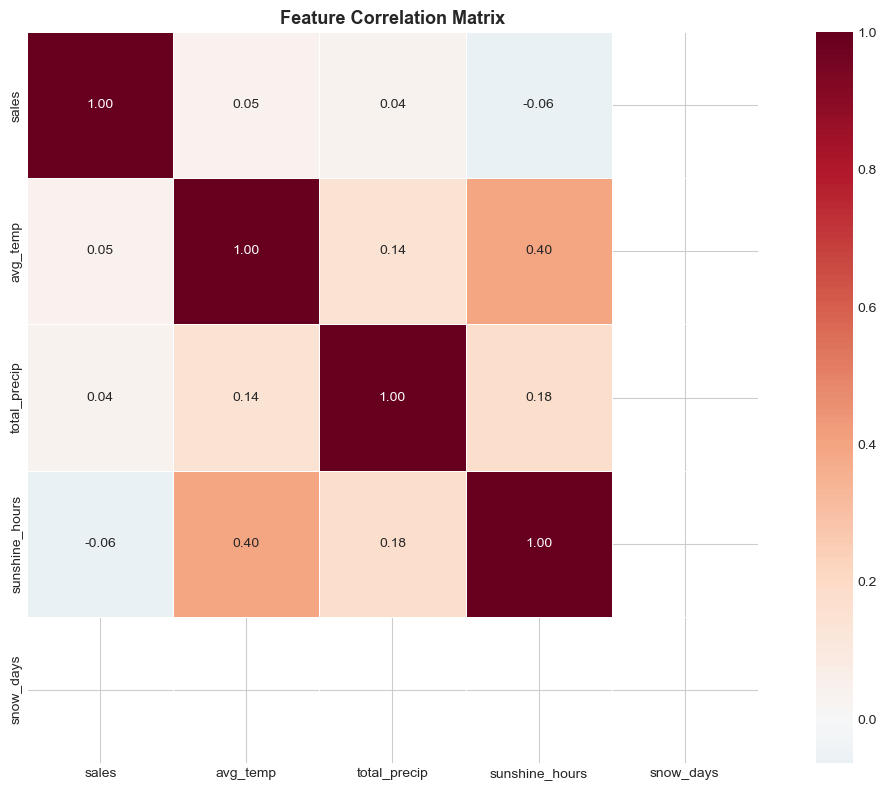

✅ Saved: feature_correlation.png

Division-specific correlations with sales:
AM    avg_temp vs sales correlation: -0.093
AP    avg_temp vs sales correlation: 0.269
AS    avg_temp vs sales correlation: 0.119
AZ    avg_temp vs sales correlation: -0.520
BQ    avg_temp vs sales correlation: 0.159
CA    avg_temp vs sales correlation: 1.000
CC    avg_temp vs sales correlation: 0.282
CH    avg_temp vs sales correlation: 0.026
CR    avg_temp vs sales correlation: 0.533
DI    avg_temp vs sales correlation: -0.113
FI    avg_temp vs sales correlation: -0.035
GA    avg_temp vs sales correlation: -0.116
HT    avg_temp vs sales correlation: -0.201
IN    avg_temp vs sales correlation: -0.176
INM   avg_temp vs sales correlation: -0.143
LI    avg_temp vs sales correlation: 0.145
LO    avg_temp vs sales correlation: 0.410
ME    avg_temp vs sales correlation: 0.390
MK    avg_temp vs sales correlation: 0.085
PA    avg_temp vs sales correlation: 0.253
PC    avg_temp vs sales correlation: 0.172
PI    avg_te

In [25]:
all_feat = (
    SEASONALITY_FEATURES
    + CALENDAR_FEATURES
    + [c for c in WEATHER_FEATURES if c in df.columns]
    + WEATHER_LAG_FEATURES
    + [c for c in LAG_FEATURES if c in df.columns]
)
all_feat = [c for c in all_feat if c in df.columns]

corr = df[['units'] + all_feat].corr()['units'].drop('units').sort_values(ascending=False)

print('Feature correlations with weekly sales (top 20):')
print('='*50)
for feat, val in corr.head(20).items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<35} {sign}{abs(val):.3f}  {bar}')

# Heatmap: weather vs sales
hm_cols = ['units'] + [c for c in WEATHER_RAW if c in df.columns]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df[hm_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_correlation.png')

print("\nDivision-specific correlations with sales:")
print("="*50)

for div, g in df.groupby('division_code'):
    corr = g[['units','avg_temp']].corr().iloc[0,1]
    print(f'{div:<5} avg_temp vs sales correlation: {corr:.3f}')

---
## Cell 8: Save Modeling Dataset
---

In [24]:
df.to_csv(DATA_PROCESSED / 'modeling_dataset.csv', index=False)
print(f'✅ Saved: modeling_dataset.csv ({df.shape[0]:,} rows × {df.shape[1]} cols)')
print("""
Feature Summary:
  Seasonality   : sin/cos Fourier terms (week + month)
  Calendar      : year_idx, quarter, season flags, holidays
  Weather (raw) : avg_temp, total_precip, sunshine_hours, rain_days, snow_days, bad_weather_days
  Weather (dev) : *_dev_z (z-score deviation from monthly city norm)
  Thresholds    : temp_above_20/25, temp_below_0, cooling/heating degree days
  Lag features  : 1w, 2w, 4w lags + 4-week rolling (for non-Prophet models)

Next → 04_forecast_model.ipynb
""")

✅ Saved: modeling_dataset.csv (1,333 rows × 56 cols)

Feature Summary:
  Seasonality   : sin/cos Fourier terms (week + month)
  Calendar      : year_idx, quarter, season flags, holidays
  Weather (raw) : avg_temp, total_precip, sunshine_hours, rain_days, snow_days, bad_weather_days
  Weather (dev) : *_dev_z (z-score deviation from monthly city norm)
  Thresholds    : temp_above_20/25, temp_below_0, cooling/heating degree days
  Lag features  : 1w, 2w, 4w lags + 4-week rolling (for non-Prophet models)

Next → 04_forecast_model.ipynb

